--- Dataset Summary ---
<xarray.Dataset> Size: 84MB
Dimensions:     (valid_time: 720, latitude: 111, longitude: 131)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2025-11-01 ... 2025-11-30T23:...
    expver      (valid_time) <U4 12kB ...
  * latitude    (latitude) float64 888B 47.0 46.9 46.8 46.7 ... 36.2 36.1 36.0
  * longitude   (longitude) float64 1kB 6.0 6.1 6.2 6.3 ... 18.7 18.8 18.9 19.0
    number      int64 8B ...
Data variables:
    ro          (valid_time, latitude, longitude) float32 42MB ...
    tp          (valid_time, latitude, longitude) float32 42MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-12T08:25 GRIB to CDM+CF via cfgrib-0.9.1...

--- Data Preview (First 5 rows) ---
                  

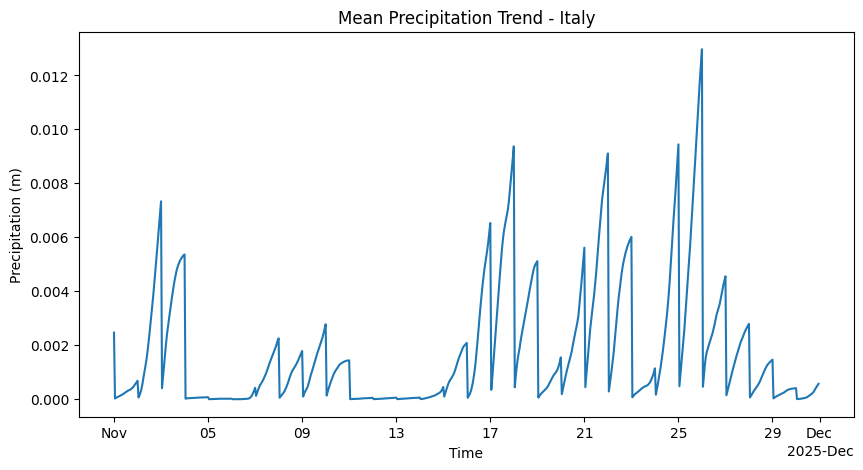

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt


file_path = 'italy_flood_data.nc' 

try:
    
    ds = xr.open_dataset(file_path)

    
    print("--- Dataset Summary ---")
    print(ds)

    
    df_preview = ds.to_dataframe().head()
    print("\n--- Data Preview (First 5 rows) ---")
    print(df_preview)

    
    if 'tp' in ds.variables:
        ds.tp.mean(dim=['latitude', 'longitude']).plot(figsize=(10, 5))
        plt.title('Mean Precipitation Trend - Italy')
        plt.xlabel('Time')
        plt.ylabel('Precipitation (m)')
        plt.show()

except Exception as e:
    print(f"Error occurred: {e}")

In [3]:

df = ds.to_dataframe().reset_index()


df.to_csv('italy_flood_summary.csv', index=False)

print("Great! Your CSV file is ready.")

Great! Your CSV file is ready.


In [4]:

genoa_clean = df[(df['latitude'] == 44.4) & (df['longitude'] == 8.9)].copy()


genoa_clean.to_csv('genoa_final_data.csv', index=False)

print("Finished! Now open 'genoa_final_data.csv' - it will be very fast.")

Finished! Now open 'genoa_final_data.csv' - it will be very fast.


In [5]:

genoa_exact = ds.sel(latitude=44.4, longitude=8.9, method='nearest').to_dataframe().reset_index()


genoa_exact.to_csv('genoa_final_data.csv', index=False)

print("Check the folder now! 'genoa_final_data.csv' should be full of data.")

Check the folder now! 'genoa_final_data.csv' should be full of data.


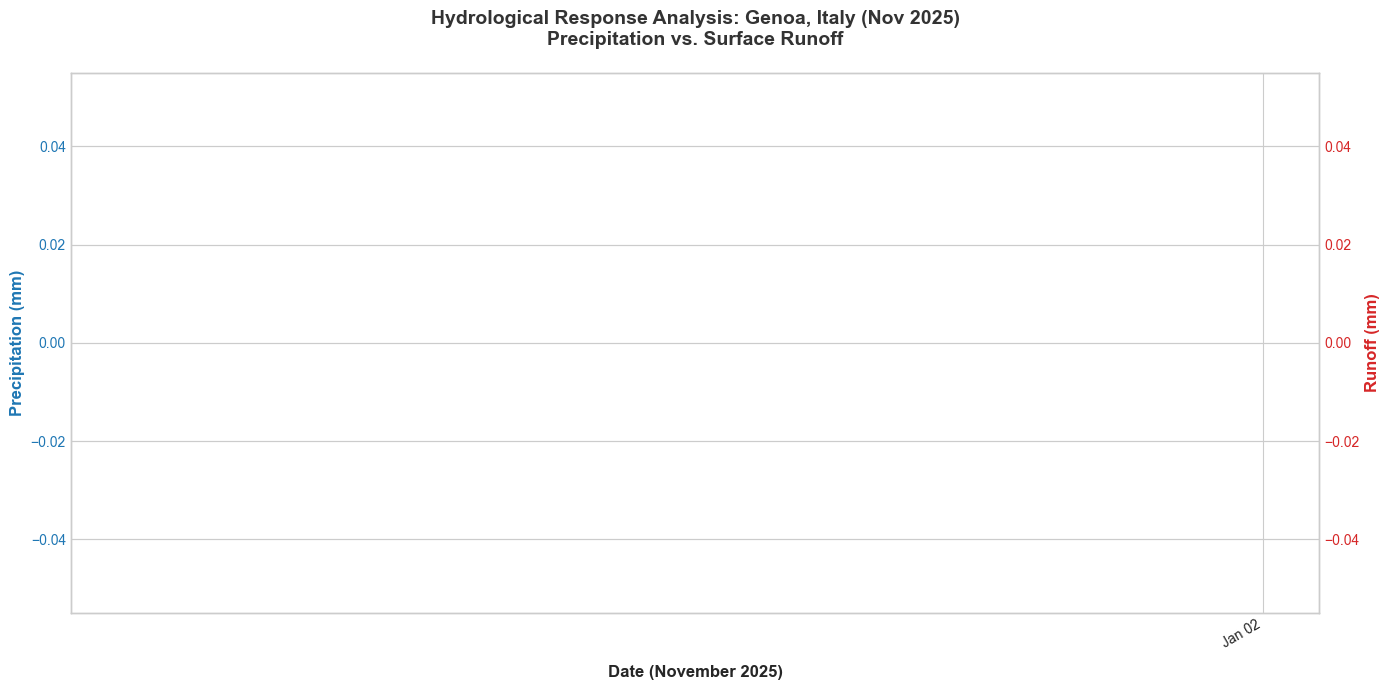

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


df = pd.read_csv('genoa_final_data.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])


plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)


color = '#1f77b4' # Blue color for rain
ax1.set_xlabel('Date (November 2025)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Precipitation (mm)', color=color, fontsize=12, fontweight='bold')
ax1.plot(df['valid_time'], df['tp'] * 1000, color=color, linewidth=2, label='Precipitation (mm)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.fill_between(df['valid_time'], df['tp'] * 1000, color=color, alpha=0.15)


ax2 = ax1.twinx()
color = '#d62728' # Red color for runoff
ax2.set_ylabel('Runoff (mm)', color=color, fontsize=12, fontweight='bold')
ax2.plot(df['valid_time'], df['ro'] * 1000, color=color, linewidth=2, linestyle='--', label='Runoff (mm)')
ax2.tick_params(axis='y', labelcolor=color)


ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
fig.autofmt_xdate()


plt.title('Hydrological Response Analysis: Genoa, Italy (Nov 2025)\nPrecipitation vs. Surface Runoff', 
          fontsize=14, fontweight='bold', pad=20, color='#333333')

fig.tight_layout()
plt.show()